# Fourieroptik Teil B: Quantitative Beobachtungen am Einzelspalt

Diesen Teil können Sie direkt im Notebook bearbeiten. Als Protokoll geben Sie bitte ab:
- das lauffähige Notebook zu Teil B und ein pdf des Notebooks zu Teil B. Passen Sie das Notebook vor Abgabe bitte so an, dass folgendes enthalten ist:
    - Ihr kommentierter Code (incl. der benötigten Teile, die schon vorher enthalten waren. Vorher enthaltene längere Anleitungen, ungenutzten Code etc. bitte zur Übersichtlichkeit entfernen)
    - Ihre Plots und Ergebnisse der Auswertung incl. Kommentare
    - Interpretationen und Antworten auf die gestellten Fragen. Fügen Sie hierfür Textfelder ein. Lassen Sie Zahlenergebnisse und Plots nicht kommentiert ohne Romane zu schreiben. Das Protokoll sollte mit Kenntnis der Anleitung, ohne dass diese parallel gelesen werden muss, nachvollziehbar sein. (Ein kurzer Satz, welche Aufgabe inhaltlich bearbeitet wird, ist ausreichend, eine Aufgabennummer nicht.)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## Analyse der Beugungsstruktur am Einzelspalt

Im zip-Ordner "Data" sind die Messdaten des Beugungsbilds eines Einzelspalts enthalten:
- Kalibrationsdaten für die Umrechnung von Pixel zu mm: "Kalibration der Abszisse.txt"
- Messung Beugungsbilder des Einzelspalts: Messung1 (Hauptmaximum komplett enthalten) und Messung2 (vergrößert, Hauptmaximum abgeschnitten)

Vergleichen Sie die Messdaten des Beugungsbild des Einzelspalts mit der theoretisch zu erwartenden Beugungsstruktur und bestimmen Sie aus den Messdaten die Spaltbreite. Gehen Sie hierzu folgendermaßen vor:

1. Plotten Sie das gemessene Beugungsbild und fitten Sie die erwartete Beugungsstruktur an die Messung. Nutzen Sie hierfür Ihr Ergebnis aus der Aufgabe in Abschnitt 2.3 der Versuchsanleitung. Kommentieren Sie das Ergebnis und ggf. auftretende Abweichungen.
2. Vermutlich haben Sie festgestellt, dass 1. nicht sonderlich gut funktioniert. Eine (funktionierende) Möglichkeit ist, die Spaltbreite aus der Position der Minima des Beugungsbildes zu bestimmen. Die Beziehung zwischen Spaltbreite und Position der Minima ist in der Versuchsanleitung gegeben. Gehen Sie folgendermaßen vor:
- Lesen Sie die Positionen der Minima (in mm) aus dem gemessenen Beugungsbild ab.
- Plotten Sie die Positionen der Minima incl. geschätzter Fehlerbalken gegen die Ordnungszahl der Minima.
- Bestimmen Sie die Spaltbreite (incl. Unsicherheit) mithilfe eines Fits

Hinweise:
- Es muss eine Kalibration durchgeführt werden, um aus der Pixelposition der Kamera die Position in mm zu bestimmen. Verwenden Sie hierzu die Datei "Kalibration der Abszisse.txt".
- Neben statistischen Messunsicherheiten treten bei der Kameraaufnahme auch Effekte wie Hintergrundrauschen und Nichtlinearitäten in der Intensitätsmessung auf.


In [2]:
# Code Schnipsel

# interaktiver Plot zum Ablesen von Werten (funktioniert leider nicht in jeder Umgebung)
%matplotlib notebook
# nutzen Sie matplotlib notebook nur wo nötig, da die interaktiven Plots viel Rechenleistung benötigen
%matplotlib inline
# Daten plotten in interaktivem Graph auf dem Jupyter Server (zum Ablesen der Minima bei 2.)
#import plotly.express as px
#fig=px.scatter(data, x='Position', y='Messwerte', title='interaktives Streudiagramm')
#fig.update_xaxes(title_text='Position / mm')
#fig.update_yaxes(title_text='counts')
#fig.show()

# mit matplotlib inline erzeugen Sie "normale" Plots

# Plot mit Fehlerbalken. Für y_errors übergeben Sie ein Array der korrekten Größe
# plt.errorbar(x, y, yerr=y_errors, fmt='o', label='Messwerte')
# Beim Fit können Sie sigma=y_errors und absolute_sigma=True übergeben, um die (in absoluten Werten angegebenen) Unsicherheiten sowohl beim Fit als auch bei der berechneten Kovarianzmatrix zu berücksichtigen.
# popt, pcov = curve_fit(fit_function, x, y, sigma=y_errors, absolute_sigma=True)

,Pixel,Messuhr[mm]
0,760.19,1.510
1,828.00,1.330
2,897.16,1.110
3,965.31,0.897
4,1032.45,0.699
5,1100.26,0.488
6,1168.41,0.255


Kalibrations-Fit: x[mm] = -0.003077 * Pixel + 3.866273


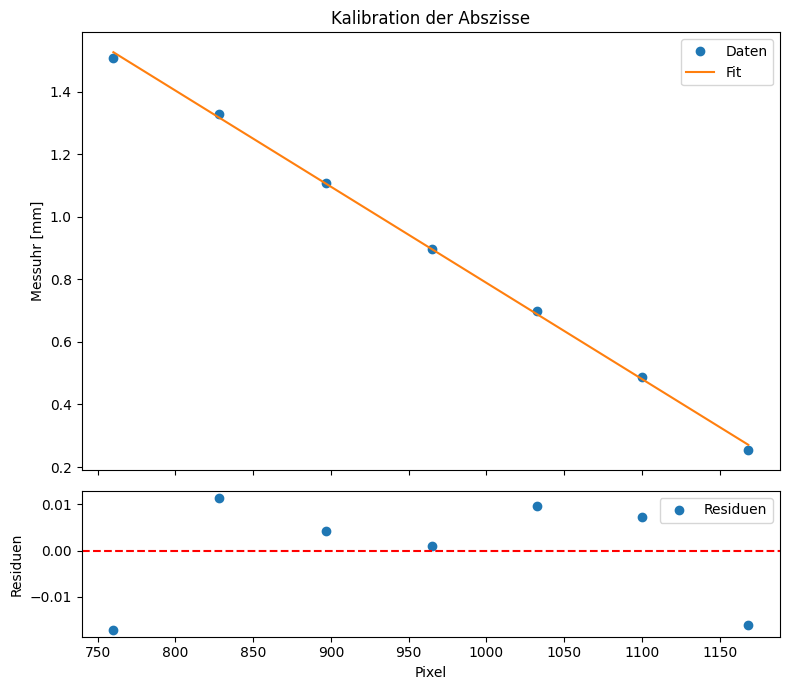

In [3]:
# TODO: Kalibration durchführen
data=pd.read_csv('Data/Kalibration der Abszisse.txt', sep=' ')
display(data)

# Wir fitten ein lineares Modell: x_mm = m * Pixel + c
def lin_fit(x, m, c):
    return m * x + c

popt_cal, pcov_cal = curve_fit(lin_fit, data['Pixel'], data['Messuhr[mm]'])
print(f"Kalibrations-Fit: x[mm] = {popt_cal[0]:.6f} * Pixel + {popt_cal[1]:.6f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
ax1.plot(data['Pixel'], data['Messuhr[mm]'], 'o', label='Daten')
ax1.plot(data['Pixel'], lin_fit(data['Pixel'], *popt_cal), '-', label='Fit')
ax1.set_ylabel('Messuhr [mm]')
ax1.legend()
ax1.set_title('Kalibration der Abszisse')

residuals_cal = data['Messuhr[mm]'] - lin_fit(data['Pixel'], *popt_cal)
ax2.plot(data['Pixel'], residuals_cal, 'o', label='Residuen')
ax2.axhline(0, color='r', linestyle='--')
ax2.set_xlabel('Pixel')
ax2.set_ylabel('Residuen')
ax2.legend()

plt.tight_layout()
plt.show()

# Funktion zur Umrechnung von Pixel in mm
def pixel_to_mm(pixel):
    return lin_fit(pixel, *popt_cal)


Fit erfolgreich!


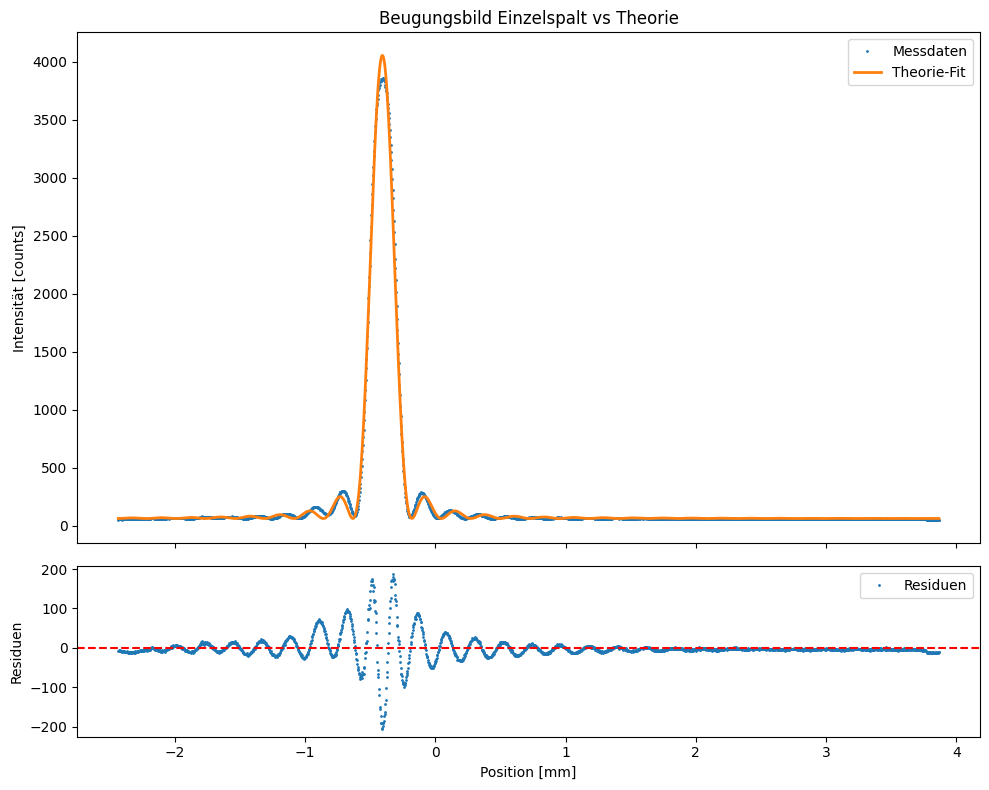

In [4]:
# TODO: Beugungsbild des Einzelspalts mit theoretischer Beugungsstruktur vergleichen
messung1 = pd.read_csv('Data/Messung1.txt', sep=' ')
# Pixel in mm umrechnen
messung1['x_mm'] = pixel_to_mm(messung1['pixel'])

# Sinc-Funktion definieren
# I(x) = I_0 * (sin(alpha * (x - x0)) / (alpha * (x - x0)))^2 + I_bg
def sinc_fit(x, I_0, a, x0, I_bg):
    # np.sinc(y) berechnet sin(pi*y)/(pi*y). Daher teilen wir das innere Argument durch pi.
    return I_0 * (np.sinc(a * (x - x0) / np.pi))**2 + I_bg

# Startwerte für den Fit schätzen
x0_guess = messung1.loc[messung1['counts'].idxmax(), 'x_mm']
I_0_guess = messung1['counts'].max() - messung1['counts'].min()
I_bg_guess = messung1['counts'].min()
a_guess = 10.0 

p0 = [I_0_guess, a_guess, x0_guess, I_bg_guess]

try:
    popt_sinc, pcov_sinc = curve_fit(sinc_fit, messung1['x_mm'], messung1['counts'], p0=p0)
    print("Fit erfolgreich!")
    fit_erfolgreich = True
except Exception as e:
    print("Fit fehlgeschlagen:", e)
    fit_erfolgreich = False

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
ax1.plot(messung1['x_mm'], messung1['counts'], '.', label='Messdaten', markersize=2)

if fit_erfolgreich:
    x_plot = np.linspace(messung1['x_mm'].min(), messung1['x_mm'].max(), 1000)
    ax1.plot(x_plot, sinc_fit(x_plot, *popt_sinc), '-', label='Theorie-Fit', linewidth=2)
    
    residuals = messung1['counts'] - sinc_fit(messung1['x_mm'], *popt_sinc)
    ax2.plot(messung1['x_mm'], residuals, '.', markersize=2, label='Residuen')
    ax2.axhline(0, color='r', linestyle='--')

ax1.set_ylabel('Intensität [counts]')
ax1.set_title('Beugungsbild Einzelspalt vs Theorie')
ax1.legend()

ax2.set_xlabel('Position [mm]')
ax2.set_ylabel('Residuen')
ax2.legend()

plt.tight_layout()
plt.show()

# Kommentar:
# Der theoretische Fit weicht eventuell von der Messung ab, z.B. wenn die Kamera
# eine nicht-lineare Antwort hat, an einigen Stellen gesättigt ist oder wenn es
# störendes Hintergrundrauschen gibt. Daher ist die Methode über die Minima robuster.


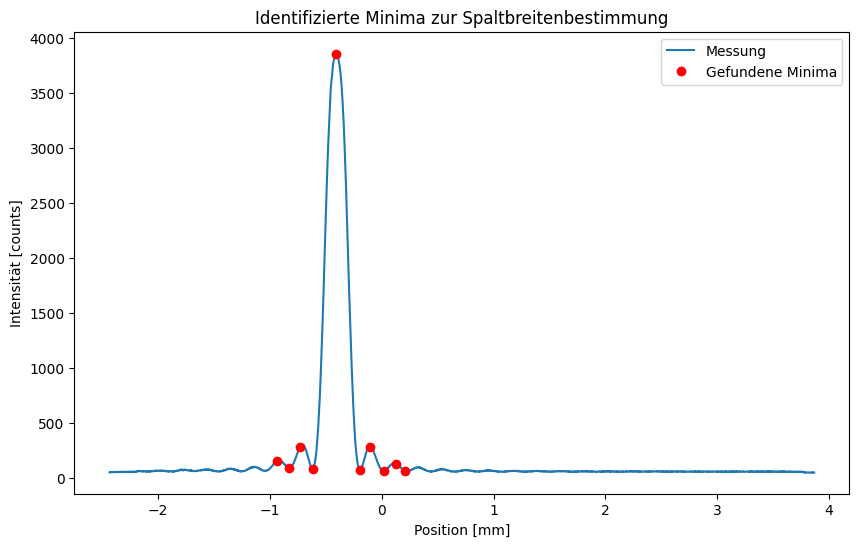

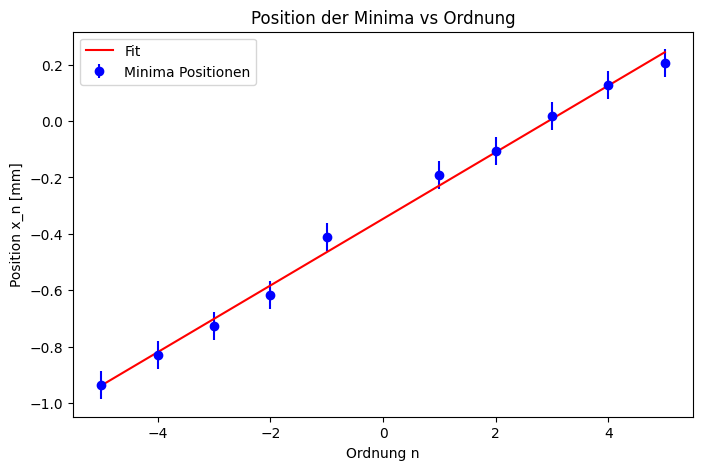

Fit-Steigung (λL/b): 0.1183 ± 0.0030 mm
Berechnete Spaltbreite b: 0.4295 ± 0.0108 mm
(λ=0.000635 mm, L=80.0 mm)


In [5]:
# TODO: Spaltbreite bestimmen
from scipy.signal import find_peaks

# Wir übergeben -counts, um die Minima (Täler) zu finden
# prominence steuert, wie deutlich das Minimum ausgeprägt sein muss
peaks, _ = find_peaks(-messung1['counts'], prominence=1, distance=10)

minima_x = messung1['x_mm'].iloc[peaks].values
minima_counts = messung1['counts'].iloc[peaks].values
x0_center = messung1.loc[messung1['counts'].idxmax(), 'x_mm']

peaks_links = np.sort([x for x in minima_x if x < x0_center])[::-1][:5]
peaks_rechts = np.sort([x for x in minima_x if x > x0_center])[:5]

minima_x_clean = []
minima_counts_clean = []
n_clean = []

for i, x in enumerate(peaks_links):
    n_clean.append(-(i+1))
    minima_x_clean.append(x)
    minima_counts_clean.append(messung1.loc[messung1['x_mm'] == x, 'counts'].values[0])
    
for i, x in enumerate(peaks_rechts):
    n_clean.append(i+1)
    minima_x_clean.append(x)
    minima_counts_clean.append(messung1.loc[messung1['x_mm'] == x, 'counts'].values[0])
    
n_clean = np.array(n_clean)
minima_x_clean = np.array(minima_x_clean)
minima_counts_clean = np.array(minima_counts_clean)

plt.figure(figsize=(10, 6))
plt.plot(messung1['x_mm'], messung1['counts'], '-', label='Messung')
plt.plot(minima_x_clean, minima_counts_clean, 'ro', label='Gefundene Minima')
plt.xlabel('Position [mm]')
plt.ylabel('Intensität [counts]')
plt.legend()
plt.title('Identifizierte Minima zur Spaltbreitenbestimmung')
plt.show()

# linearer Zusammenhang: x_n = (lambda * L / b) * n + x_0
def linear_minima(n, m, x0_):
    return m * n + x0_

popt_minima, pcov_minima = curve_fit(linear_minima, n_clean, minima_x_clean)
slope = popt_minima[0]
slope_err = np.sqrt(np.diag(pcov_minima))[0]

plt.figure(figsize=(8, 5))
plt.errorbar(n_clean, minima_x_clean, yerr=0.05, fmt='bo', label='Minima Positionen')
n_plot = np.linspace(n_clean.min(), n_clean.max(), 100)
plt.plot(n_plot, linear_minima(n_plot, *popt_minima), 'r-', label='Fit')
plt.xlabel('Ordnung n')
plt.ylabel('Position x_n [mm]')
plt.title('Position der Minima vs Ordnung')
plt.legend()
plt.show()

## GEMÄSS VERSUCHSAUFBAU ##
lambda_ = 635e-6 # in mm (635 nm)
L = 80.0 # in mm

b = (lambda_ * L) / slope
b_err = np.abs(b) * (slope_err / np.abs(slope))

print(f"Fit-Steigung (λL/b): {slope:.4f} ± {slope_err:.4f} mm")
print(f"Berechnete Spaltbreite b: {np.abs(b):.4f} ± {b_err:.4f} mm")
print(f"(λ={lambda_} mm, L={L} mm)")
